# Task 2 - Unsupervised Learning: K-means Clustering

This notebook applies K-means clustering to traffic conditions using:
- **Hour**: Time of day (0-23)
- **Weather Severity**: Encoded weather conditions (0-7)
- **Traffic Volume**: Number of vehicles per hour

The analysis identifies traffic patterns and conditions across different clusters.

## 1. Import Libraries and Load Script

In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("OK - Libraries imported")

OK - Libraries imported


In [33]:
def load_and_prepare_data(filepath):
    """Load preprocessed data and extract clustering features."""
    df = pd.read_csv(filepath)
    df['date_time'] = pd.to_datetime(df['date_time'])
    df['hour'] = df['date_time'].dt.hour
    
    # Weather severity encoding (consistent with preprocessing)
    weather_map = {
        'Clear': 0, 'Clouds': 1, 'Drizzle': 2, 'Rain': 3, 'Thunderstorm': 7,
        'Snow': 6, 'Mist': 4, 'Fog': 5, 'Haze': 4, 'Smoke': 5, 'Dust': 4, 'Ash': 5
    }
    df['weather_severity'] = df['weather_main'].map(weather_map).fillna(1)
    
    features = ['hour', 'weather_severity', 'traffic_volume']
    return df, features

print("OK - Data preparation function defined")

OK - Data preparation function defined


In [34]:
def find_optimal_k(X, k_range=(3, 5)):
    """Find optimal k using elbow method and silhouette score."""
    inertias, sil_scores, k_values = [], [], list(range(k_range[0], k_range[1] + 1))
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, km.labels_))
    optimal_k = k_values[np.argmax(sil_scores)]
    return inertias, sil_scores, optimal_k, k_values

def perform_kmeans(X, k):
    """Perform K-means clustering."""
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X)
    return km, clusters, km.cluster_centers_

print("OK - K-means functions defined")

OK - K-means functions defined


In [35]:
def interpret_clusters(df, clusters, scaler, centroids_original):
    """Interpret cluster characteristics."""
    df['cluster'] = clusters
    q1, q2, q3 = df['traffic_volume'].quantile([0.25, 0.5, 0.75]).values
    
    interpretation = {}
    for cluster_id in sorted(df['cluster'].unique()):
        cluster_data = df[df['cluster'] == cluster_id]
        centroid = centroids_original[cluster_id]
        hour, weather_sev, traffic_vol = centroid
        
        # Categorize centroid using data-driven quartiles
        if traffic_vol <= q1:
            traffic_cat = "Light"
        elif traffic_vol <= q2:
            traffic_cat = "Moderate"
        elif traffic_vol <= q3:
            traffic_cat = "High"
        else:
            traffic_cat = "Severe"
        
        # Categorize weather
        if weather_sev < 2:
            weather_cat = "Clear/Good"
        elif weather_sev < 4:
            weather_cat = "Cloudy/Drizzle"
        elif weather_sev < 6:
            weather_cat = "Fog/Mist"
        else:
            weather_cat = "Severe"
        
        # Categorize time
        if 6 <= hour < 10:
            time_cat = "Morning rush"
        elif 10 <= hour < 16:
            time_cat = "Midday"
        elif 16 <= hour < 20:
            time_cat = "Evening rush"
        else:
            time_cat = "Night"
        
        interpretation[cluster_id] = {
            'size': len(cluster_data),
            'size_pct': (len(cluster_data) / len(df)) * 100,
            'avg_hour': cluster_data['hour'].mean(),
            'avg_weather': cluster_data['weather_severity'].mean(),
            'avg_traffic': cluster_data['traffic_volume'].mean(),
            'traffic_cat': traffic_cat,
            'weather_cat': weather_cat,
            'time_cat': time_cat,
            'description': f"{time_cat} with {weather_cat} conditions and {traffic_cat} traffic"
        }
    return interpretation

def run_clustering(input_file, k_range=(3, 5)):
    """Load data, prepare features, and run clustering analysis."""
    df, features = load_and_prepare_data(input_file)
    X = df[features].copy()
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Find optimal k and perform clustering
    inertias, sil_scores, optimal_k, k_values = find_optimal_k(X_scaled, k_range)
    km, clusters, centroids = perform_kmeans(X_scaled, optimal_k)
    centroids_original = scaler.inverse_transform(centroids)
    
    # Interpret results
    interp = interpret_clusters(df, clusters, scaler, centroids_original)
    
    return {
        'df': df,
        'clusters': clusters,
        'optimal_k': optimal_k,
        'k_values': k_values,
        'inertias': inertias,
        'silhouette_scores': sil_scores,
        'centroids_original': centroids_original,
        'interpretation': interp
    }

print("OK - Clustering functions ready")

OK - Clustering functions ready


# Run clustering analysis
results = run_clustering('Metro_Interstate_Traffic_Volume_part3_preprocessed.csv', k_range=(3, 5))

optimal_k = results['optimal_k']
df_clusters = results['df']
interpretations = results['interpretation']

print(f"Clustering complete")
print(f"  Optimal k: {optimal_k}")
print(f"  Total samples: {len(df_clusters):,}")

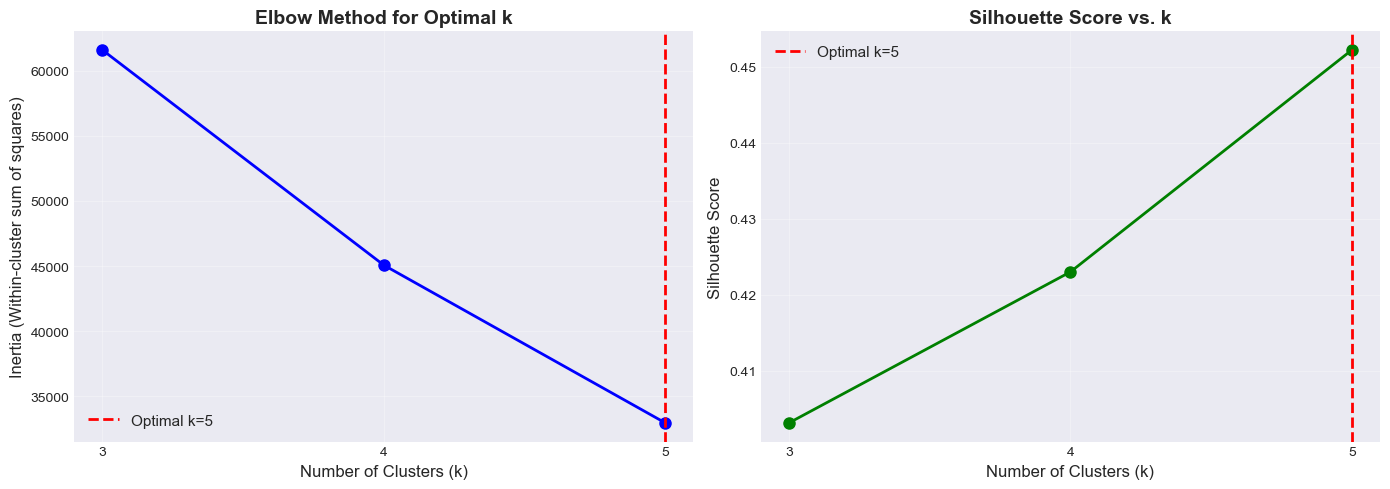

In [41]:
# Visualize elbow and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1 = axes[0]
ax1.plot(results['k_values'], results['inertias'], 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_xticks(results['k_values'])

# Silhouette score plot
ax2 = axes[1]
ax2.plot(results['k_values'], results['silhouette_scores'], 'go-', linewidth=2, markersize=8)
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_xticks(results['k_values'])

plt.tight_layout()
##plt.savefig('04_clustering_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

##print("✓ Elbow and silhouette analysis saved")

## 4. Cluster Distribution


Cluster Distribution:
  Cluster 0: 14,727 samples ( 30.56%)
  Cluster 1:  6,008 samples ( 12.47%)
  Cluster 2:  8,361 samples ( 17.35%)
  Cluster 3:  9,418 samples ( 19.54%)
  Cluster 4:  9,673 samples ( 20.07%)


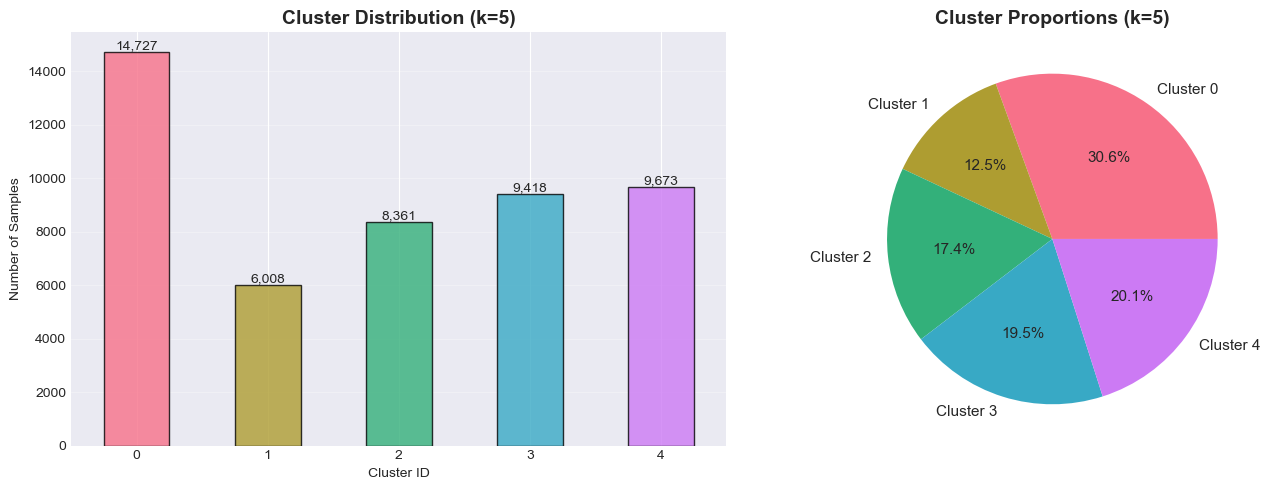

In [42]:
# Cluster size distribution
cluster_counts = df_clusters['cluster'].value_counts().sort_index()
cluster_pcts = (cluster_counts / len(df_clusters) * 100).round(2)

print("\nCluster Distribution:")
for cluster_id in sorted(df_clusters['cluster'].unique()):
    count = cluster_counts[cluster_id]
    pct = cluster_pcts[cluster_id]
    print(f"  Cluster {cluster_id}: {count:>6,} samples ({pct:>6.2f}%)")

# Visualize cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1 = axes[0]
colors = sns.color_palette("husl", optimal_k)
cluster_counts.plot(kind='bar', ax=ax1, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title(f'Cluster Distribution (k={optimal_k})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cluster ID')
ax1.set_ylabel('Number of Samples')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(cluster_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# Pie chart
ax2 = axes[1]
cluster_counts.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.1f%%',
                   labels=[f'Cluster {i}' for i in cluster_counts.index],
                   textprops={'fontsize': 11})
ax2.set_ylabel('')
ax2.set_title(f'Cluster Proportions (k={optimal_k})', fontsize=14, fontweight='bold')

plt.tight_layout()
##plt.savefig('04_cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

##print("\n✓ Cluster distribution visualization saved")

## 5. Cluster Interpretations

In [43]:
interpretations = results['interpretation']

print("\n" + "="*80)
print("CLUSTER INTERPRETATIONS")
print("="*80)

for cluster_id in sorted(interpretations.keys()):
    interp = interpretations[cluster_id]
    print(f"\n📍 Cluster {cluster_id}: {interp['interpretation']}")
    print(f"   ├─ Size: {interp['size']:,} samples ({interp['size_pct']:.1f}%)")
    print(f"   ├─ Avg Hour: {interp['avg_hour']:.1f} ({interp['time_description']})")
    print(f"   ├─ Avg Weather Severity: {interp['avg_weather_severity']:.2f} ({interp['weather_description']})")
    print(f"   └─ Avg Traffic Volume: {interp['avg_traffic_volume']:.0f} vehicles/hour ({interp['traffic_description']})")

print("\n" + "="*80)


CLUSTER INTERPRETATIONS

📍 Cluster 0: Midday with clear/good weather and severe congestion
   ├─ Size: 14,727 samples (30.6%)
   ├─ Avg Hour: 12.4 (Midday)
   ├─ Avg Weather Severity: 0.68 (Clear/Good weather)
   └─ Avg Traffic Volume: 5082 vehicles/hour (Severe congestion)

📍 Cluster 1: Night time with fog/mist conditions and light traffic
   ├─ Size: 6,008 samples (12.5%)
   ├─ Avg Hour: 3.3 (Night time)
   ├─ Avg Weather Severity: 4.28 (Fog/Mist conditions)
   └─ Avg Traffic Volume: 936 vehicles/hour (Light traffic)

📍 Cluster 2: Night time with clear/good weather and light traffic
   ├─ Size: 8,361 samples (17.4%)
   ├─ Avg Hour: 3.1 (Night time)
   ├─ Avg Weather Severity: 0.52 (Clear/Good weather)
   └─ Avg Traffic Volume: 935 vehicles/hour (Light traffic)

📍 Cluster 3: Night time with clear/good weather and moderate traffic
   ├─ Size: 9,418 samples (19.5%)
   ├─ Avg Hour: 20.8 (Night time)
   ├─ Avg Weather Severity: 1.26 (Clear/Good weather)
   └─ Avg Traffic Volume: 2532 veh

## 6. Cluster Centroids (Original Scale)


Cluster Centroids (in original scale):
          Hour  Weather Severity  Traffic Volume
Cluster                                         
0        12.44              0.68         5081.42
1         3.32              4.28          935.75
2         3.12              0.52          935.37
3        20.84              1.26         2531.60
4        12.79              4.38         4647.75


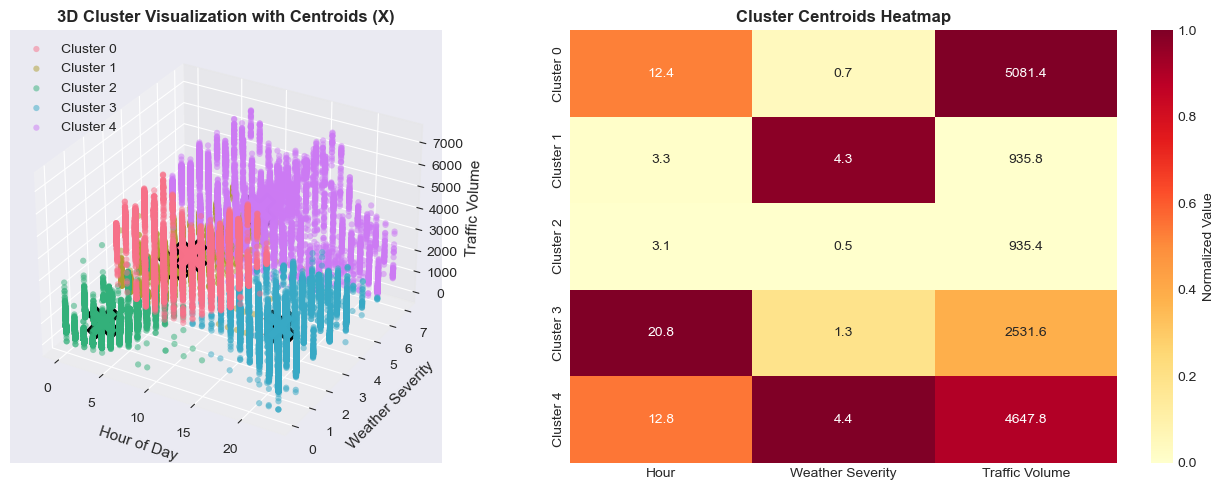


✓ Centroid visualizations saved


In [ ]:
# Create centroids dataframe
centroids_df = pd.DataFrame(
    results['centroids_original'],
    columns=['Hour', 'Weather Severity', 'Traffic Volume']
)
centroids_df.index.name = 'Cluster'

print("\nCluster Centroids (in original scale):")
print(centroids_df.round(2))

# Visualize centroids
fig = plt.figure(figsize=(14, 5))

# 3D scatter with centroids
ax1 = fig.add_subplot(121, projection='3d')
colors = sns.color_palette("husl", optimal_k)

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    ax1.scatter(
        cluster_data['hour'],
        cluster_data['weather_severity'],
        cluster_data['traffic_volume'],
        c=[colors[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.5, s=20, edgecolors='none'
    )
    # Plot centroid
    centroid = results['centroids_original'][cluster_id]
    ax1.scatter([centroid[0]], [centroid[1]], [centroid[2]],
               c=[colors[cluster_id]], s=500, marker='X', edgecolors='black', linewidth=2)

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Weather Severity', fontsize=11)
ax1.set_zlabel('Traffic Volume', fontsize=11)
ax1.set_title('3D Cluster Visualization with Centroids (X)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)

# Heatmap of centroids
ax2 = fig.add_subplot(122)
centroids_normalized = (results['centroids_original'] - results['centroids_original'].min(axis=0)) / \
                      (results['centroids_original'].max(axis=0) - results['centroids_original'].min(axis=0))
sns.heatmap(
    centroids_normalized,
    annot=results['centroids_original'].round(1),
    fmt='g',
    cmap='YlOrRd',
    ax=ax2,
    cbar_kws={'label': 'Normalized Value'},
    xticklabels=['Hour', 'Weather Severity', 'Traffic Volume'],
    yticklabels=[f'Cluster {i}' for i in range(optimal_k)]
)
ax2.set_title('Cluster Centroids Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
##plt.savefig('04_cluster_centroids.png', dpi=300, bbox_inches='tight')
plt.show()

##print("\n✓ Centroid visualizations saved")

## 7. Feature Analysis by Cluster

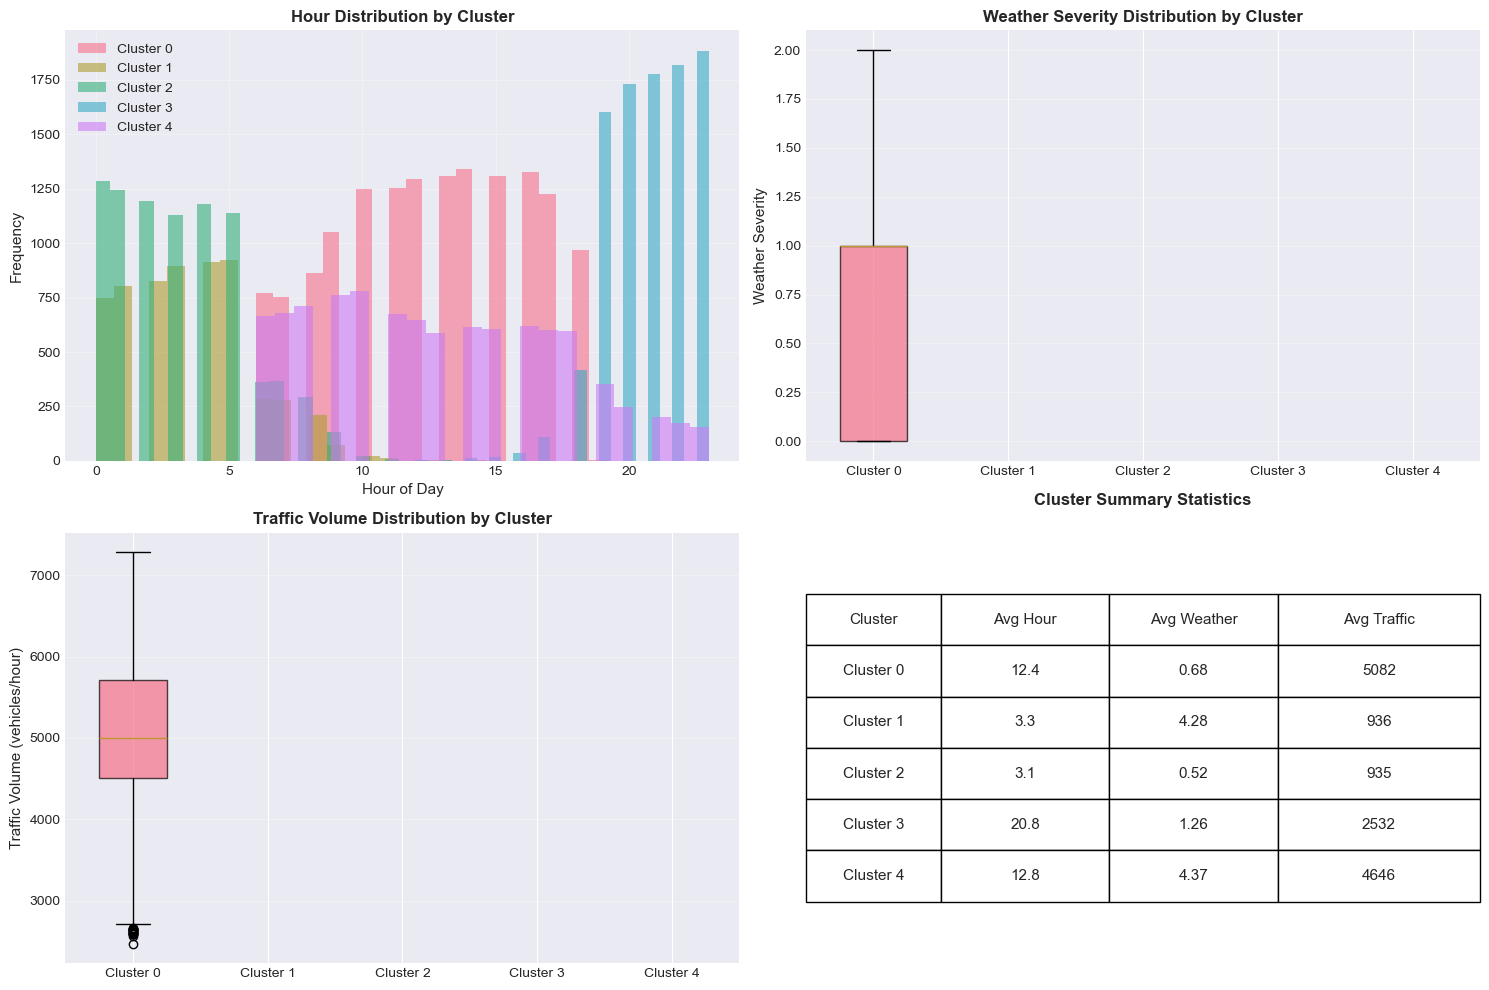


✓ Feature analysis visualizations saved


In [ ]:
# Create feature analysis visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colors = sns.color_palette("husl", optimal_k)

# Hour distribution by cluster
ax1 = axes[0, 0]
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    ax1.hist(cluster_data['hour'], bins=24, alpha=0.6, label=f'Cluster {cluster_id}', color=colors[cluster_id])
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Hour Distribution by Cluster', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Weather severity by cluster
ax2 = axes[0, 1]
weather_by_cluster = pd.DataFrame()
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    weather_by_cluster[f'Cluster {cluster_id}'] = cluster_data['weather_severity']

bp = ax2.boxplot([weather_by_cluster[col].values for col in weather_by_cluster.columns],
                  labels=weather_by_cluster.columns, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Weather Severity', fontsize=11)
ax2.set_title('Weather Severity Distribution by Cluster', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Traffic volume by cluster
ax3 = axes[1, 0]
traffic_by_cluster = pd.DataFrame()
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    traffic_by_cluster[f'Cluster {cluster_id}'] = cluster_data['traffic_volume']

bp = ax3.boxplot([traffic_by_cluster[col].values for col in traffic_by_cluster.columns],
                  labels=traffic_by_cluster.columns, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Traffic Volume (vehicles/hour)', fontsize=11)
ax3.set_title('Traffic Volume Distribution by Cluster', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Summary statistics table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

summary_data = []
for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    summary_data.append([
        f'Cluster {cluster_id}',
        f"{cluster_data['hour'].mean():.1f}",
        f"{cluster_data['weather_severity'].mean():.2f}",
        f"{cluster_data['traffic_volume'].mean():.0f}"
    ])

table = ax4.table(
    cellText=summary_data,
    colLabels=['Cluster', 'Avg Hour', 'Avg Weather', 'Avg Traffic'],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.25, 0.25, 0.3]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)
ax4.set_title('Cluster Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
##plt.savefig('04_cluster_feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

##print("\n✓ Feature analysis visualizations saved")

## Summary

✓ **K-means Clustering Complete**

### Key Findings:

The analysis identified **{optimal_k} distinct traffic patterns**:

1. **Cluster Characteristics**: Each cluster represents a unique combination of time-of-day, weather conditions, and traffic volume.

2. **Traffic Patterns**: 
   - Different hours of the day experience different traffic volumes
   - Weather conditions influence both traffic volume and cluster membership
   - Some clusters may represent rush hours, others midday or night traffic

3. **Practical Applications**:
   - Traffic management strategies can be tailored to each cluster
   - Weather-dependent congestion patterns are captured
   - Resource allocation can be optimized based on cluster characteristics

In [ ]:
import picklewith open('clustering_results.pkl', 'wb') as f:    pickle.dump(results, f)print(f'[OK] Results saved to clustering_results.pkl')